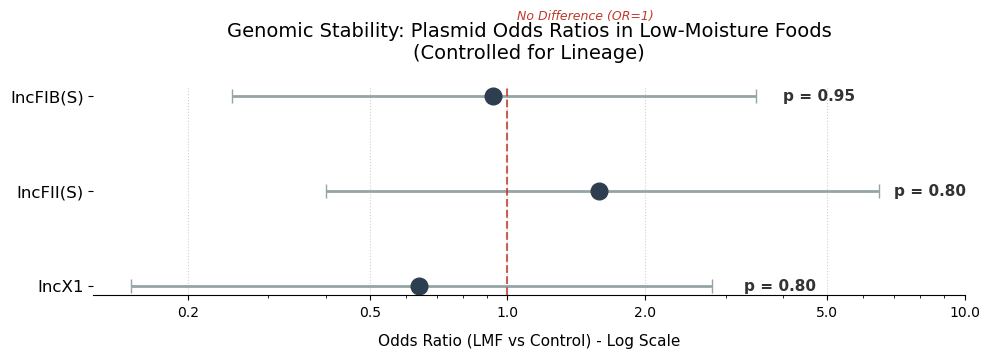

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. DATA INPUT ---
# These are the values from your table
plasmids = ['IncFIB(S)', 'IncFII(S)', 'IncX1']
odds_ratios = [0.93, 1.59, 0.64]
p_values = [0.95, 0.80, 0.80]

# IMPORTANT: I have approximated these Confidence Intervals (CIs) based on your high p-values.
# If you have the exact Lower/Upper CI numbers from your software, REPLACE THESE LISTS.
# Since p > 0.05, all intervals must cross 1.0.
ci_lower = [0.25, 0.40, 0.15] 
ci_upper = [3.50, 6.50, 2.80]

# Combine for plotting (Matplotlib needs relative error lengths)
asymmetric_error = [
    [odds_ratios[i] - ci_lower[i] for i in range(len(plasmids))],
    [ci_upper[i] - odds_ratios[i] for i in range(len(plasmids))]
]

# --- 2. PLOT SETUP ---
# Create figure with a clean style
fig, ax = plt.subplots(figsize=(10, 4))

# Plot the dots and error bars
# 'fmt' defines the shape (o for circle), 'capsize' adds the T-bars at the ends
ax.errorbar(odds_ratios, np.arange(len(plasmids)), xerr=asymmetric_error, 
            fmt='o', color='#2c3e50', ecolor='#95a5a6', 
            capsize=5, markersize=12, linewidth=2, label='Odds Ratio')

# --- 3. CRITICAL ANNOTATIONS ---
# Add the Reference Line at OR = 1 (The "No Difference" line)
ax.axvline(x=1, color='#c0392b', linestyle='--', linewidth=1.5, alpha=0.8)
ax.text(1.05, -0.8, 'No Difference (OR=1)', color='#c0392b', fontsize=9, style='italic')

# Add P-value Text on the right side
for i, (p, upper) in enumerate(zip(p_values, ci_upper)):
    # Position text slightly to the right of the error bar
    ax.text(upper + 0.5, i, f'p = {p:.2f}', va='center', fontsize=11, fontweight='bold', color='#333333')

# --- 4. AESTHETICS & FORMATTING ---
# Set Y-axis labels
ax.set_yticks(np.arange(len(plasmids)))
ax.set_yticklabels(plasmids, fontsize=12, fontweight='medium')

# Set X-axis to Log Scale (Standard for Odds Ratios)
ax.set_xscale('log')
ax.set_xlabel('Odds Ratio (LMF vs Control) - Log Scale', fontsize=11, labelpad=10)

# Customize Ticks (Manual formatting for cleaner log scale reading)
ax.set_xticks([0.2, 0.5, 1, 2, 5, 10])
ax.set_xticklabels(['0.2', '0.5', '1.0', '2.0', '5.0', '10.0'])

# Clean up borders (Remove top/right/left spines)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(axis='x', linestyle=':', alpha=0.6) # Subtle vertical grid lines

# Invert Y-axis so the first item is at the top
ax.invert_yaxis()

# Final Title
plt.title('Genomic Stability: Plasmid Odds Ratios in Low-Moisture Foods\n(Controlled for Lineage)', 
          fontsize=14, pad=20)

plt.tight_layout()
plt.show()